In [72]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
import os
import sys
import torch
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
import numpy as np

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import load_data
from episode_sampler import EpisodeSampler
from encoder import Encoder
from mamlnet import MAMLNet
from utils import deterministic
from maml_utils import train_maml, plot_maml_history

In [74]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Train

In [ ]:
data = "Mnist"
experiment_parameters = config["maml"]
n_way = experiment_parameters["n_way"]
k_shot = experiment_parameters["k_shot"]
q_query = experiment_parameters["q_query"]
meta_batch_size = experiment_parameters["meta_batch_size"]
inner_updates = experiment_parameters["inner_updates"]
meta_iterations = experiment_parameters["meta_iterations"]
in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]
alpha = experiment_parameters["alpha"]
beta = experiment_parameters["beta"]


train_images, train_labels = load_data("train", config[data]["dataset_output_dir"])
val_images, val_labels = load_data("val", config[data]["dataset_output_dir"])

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
model = MAMLNet(encoder, n_way=n_way, protomaml=False)
model.to(device)

train_sampler = EpisodeSampler(images=train_images, labels=train_labels,
                               n_way=n_way, k_shot=k_shot, q_query=q_query)

val_sampler = EpisodeSampler(images=val_images, labels=val_labels,
                             n_way=n_way, k_shot=k_shot, q_query=q_query)

optimizer = torch.optim.Adam(model.parameters(), lr=beta)

In [76]:
deterministic(config["xtra"]["seed"])
history = train_maml(model, train_sampler, val_sampler, optimizer, meta_iterations, meta_batch_size, inner_updates, alpha, device)

Meta-Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

In [77]:
path = "../models/weights/maml_mnist.pth"
model.save(path)

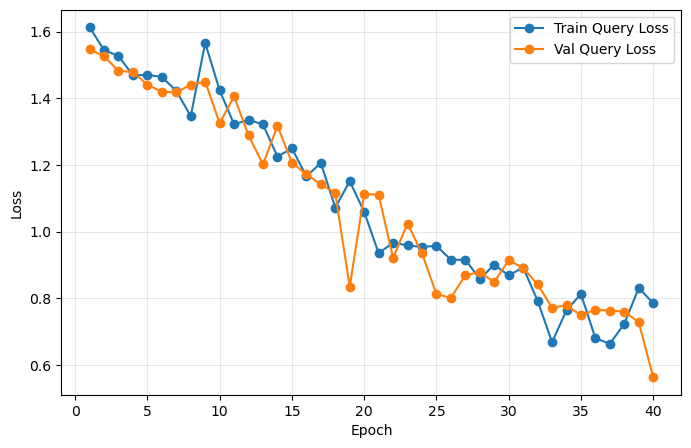

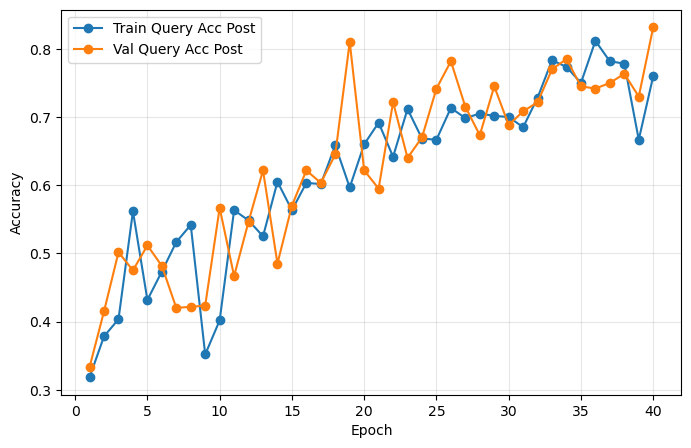

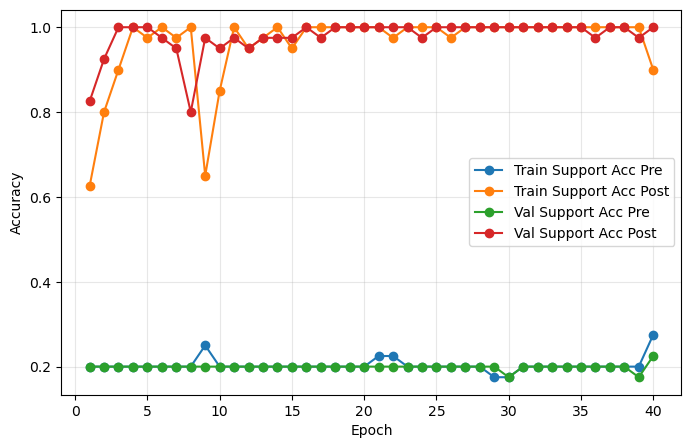

In [78]:
plot_maml_history(history)

In [79]:
print(f"Train Query Loss: {history['train_query_loss']}")
print(f"Train Support Acc Pre: {history['train_support_acc_pre']}")
print(f"Train Support Acc Post: {history['train_support_acc_post']}")
print(f"Train Query Acc Post: {history['train_query_acc_post']}")

print(f"Val Query Loss: {history['val_query_loss']}")
print(f"Val Support Acc Pre: {history['val_support_acc_pre']}")
print(f"Val Support Acc Post: {history['val_support_acc_post']}")
print(f"Val Query Acc Post: {history['val_query_acc_post']}")


Train Query Loss: [1.6130157560110092, 1.5443060994148254, 1.5268815159797668, 1.4683807641267776, 1.4700731486082077, 1.4636403173208237, 1.422315701842308, 1.346169501543045, 1.5659054815769196, 1.4237687587738037, 1.3217238187789917, 1.335389494895935, 1.321323737502098, 1.224924921989441, 1.2497475147247314, 1.165711022913456, 1.2058585211634636, 1.0716152787208557, 1.1510696485638618, 1.059212438762188, 0.9353513494133949, 0.966173842549324, 0.9586218446493149, 0.953789547085762, 0.957212571054697, 0.9152143411338329, 0.9153796285390854, 0.8580566197633743, 0.9004575237631798, 0.8684761747717857, 0.8921652138233185, 0.7925127595663071, 0.6680454835295677, 0.7643425241112709, 0.8124684765934944, 0.6799194402992725, 0.6634218953549862, 0.7234345003962517, 0.8308230713009834, 0.7853218838572502]
Train Support Acc Pre: [0.20000000298023224, 0.20000000298023224, 0.20000000298023224, 0.20000000298023224, 0.20000000298023224, 0.20000000298023224, 0.20000000298023224, 0.20000000298023224,

### ProtoMAML

In [ ]:
data = "Mnist"
experiment_parameters = config["protomaml"]
n_way = experiment_parameters["n_way"]
k_shot = experiment_parameters["k_shot"]
q_query = experiment_parameters["q_query"]
meta_batch_size = experiment_parameters["meta_batch_size"]
inner_updates = experiment_parameters["inner_updates"]
meta_iterations = experiment_parameters["meta_iterations"]
in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]
alpha = experiment_parameters["alpha"]
beta = experiment_parameters["beta"]


train_images, train_labels = load_data("train", config[data]["dataset_output_dir"])
val_images, val_labels = load_data("val", config[data]["dataset_output_dir"])

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
model = MAMLNet(encoder, n_way=n_way, protomaml=True)
model.to(device)

train_sampler = EpisodeSampler(images=train_images, labels=train_labels,
                               n_way=n_way, k_shot=k_shot, q_query=q_query)

val_sampler = EpisodeSampler(images=val_images, labels=val_labels,
                             n_way=n_way, k_shot=k_shot, q_query=q_query)

optimizer = torch.optim.Adam(model.parameters(), lr=beta)

In [81]:
deterministic(config["xtra"]["seed"])
history = train_maml(model, train_sampler, val_sampler, optimizer, meta_iterations, meta_batch_size, inner_updates, alpha, device)

Meta-Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

In [82]:
path = "../models/weights/protomaml_mnist.pth"
model.save(path)

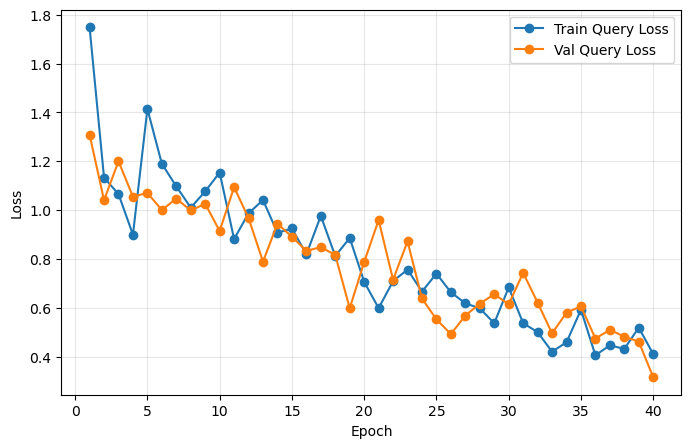

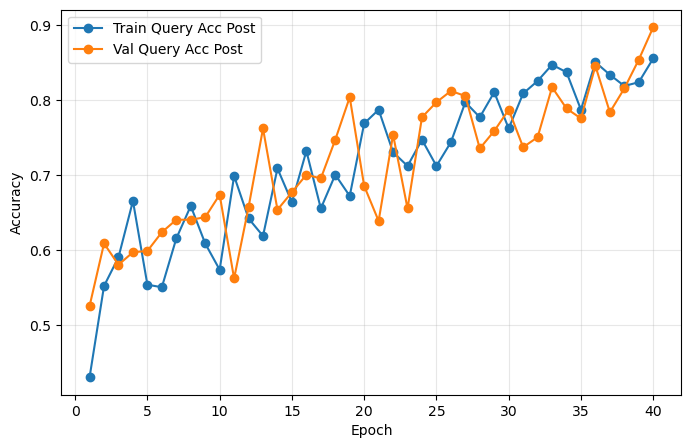

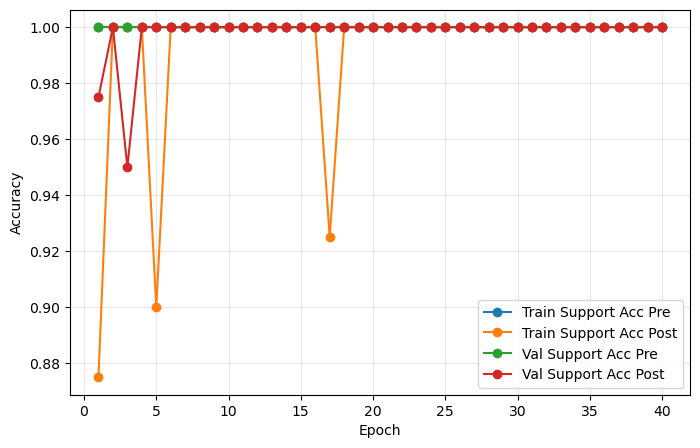

In [83]:
plot_maml_history(history)

In [84]:
print(f"Train Query Loss: {history['train_query_loss']}")
print(f"Train Support Acc Pre: {history['train_support_acc_pre']}")
print(f"Train Support Acc Post: {history['train_support_acc_post']}")
print(f"Train Query Acc Post: {history['train_query_acc_post']}")

print(f"Val Query Loss: {history['val_query_loss']}")
print(f"Val Support Acc Pre: {history['val_support_acc_pre']}")
print(f"Val Support Acc Post: {history['val_support_acc_post']}")
print(f"Val Query Acc Post: {history['val_query_acc_post']}")


Train Query Loss: [1.7493015006184578, 1.132984884083271, 1.0659267380833626, 0.8994407281279564, 1.414355643093586, 1.1899344474077225, 1.0971285924315453, 1.0102711394429207, 1.0768327713012695, 1.1540923863649368, 0.8814145177602768, 0.9872323051095009, 1.041198968887329, 0.9070040434598923, 0.9250438511371613, 0.8186783716082573, 0.9763889014720917, 0.8118157088756561, 0.8858810365200043, 0.7060075849294662, 0.5985003411769867, 0.7088034301996231, 0.7564042545855045, 0.6661110557615757, 0.7400856241583824, 0.6631194949150085, 0.6183110997080803, 0.5975570194423199, 0.5364146195352077, 0.6832971125841141, 0.5366483181715012, 0.5001612193882465, 0.4198398105800152, 0.45857213996350765, 0.5915911737829447, 0.40516606345772743, 0.44613984739407897, 0.4315378740429878, 0.5186052862554789, 0.4100748198106885]
Train Support Acc Pre: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.